# Проект «Сервис прогнозирования инцидентов и управления ремонтными работами инженерных коллекторов Москвы»

**Направление: «Пожарный риск»**

Раннее предупреждение о повышенном риске пожара/задымления в коллекторе на основе динамики показаний температурных и дымовых датчиков, состояния систем безопасности и корреляции с графиками сварочных и горячих работ (АРМ-Контроль).

## 1. Постановка задачи и описание данных

**Модель должна работать со следующим направлением прогнозирования (было выбрано 1 направление согласно ТЗ):**
«Пожарный риск» — раннее предупреждение о повышенном риске пожара/задымления в коллекторе на основе динамики показаний температурных и дымовых датчиков, корреляции с графиками сварочных и горячих работ (АРМ-Контроль)

### Структуры данных

**СПРАВОЧНИК каналов и датчиков**

 - **`ид_канала_данных`** - идентификатор канала данных (PK)
 - **`тип_инж_системы`** - тип инженерной системы (**6 подсистем**): 'Охранная подсистема', 'Пожарная охрана', 'Температурная подсистема', 'Диагностическая подсистема', 'Диспетчерский контроль', 'Газовая охрана'
 - **`тип_датчика`** (**19 типов датчиков**): 'КД АВ' (Концевой датчик АВ), 'Тепловой датчик', 'Датчик температуры', 'Датчик движения', 'КД Дверь' (Концевой датчик двери), 'Состояние охраны', 'Состояние УИР-Р' (устройство извещательное), 'Датчик дыма', 'КД Люк' (Концевой датчик люка), 'Датчик затопления', 'Ручной извещатель', 'Стекло', 'Состояние фазы', 'Состояние вентилятора', 'Переключатель', 'Газовый датчик', 'Состояние насоса', 'ИБП', '9-секционный люк'
 - **`название_датчика`**
 - **`ид_объект`** (FK)(Справочник объектов) - идентификатор объекта, на котором установлен датчик

**СПРАВОЧНИК объектов**

 - **`ид_объект`** - идентификатор объекта (PK)
 - **`иерархия_уровень`** - на каком уровне находится
 - **`родитель`** - код родительского объекта
 - **`вид_объекта`**
    - controlHouse (65) - "дом под охраной"
    - guardObject (29) - "объект под охраной"
    - district (1) - "район", "округ"
 - **`диспетчерское_название_объекта`**

**ЖУРНАЛ событий**

 - **`ид_события`** - идентификатор события (PK)
 - **`ид_канала_данных`** (FK)(Справочник каналов и датчиков)
 - **`дата`** - дата события
 - **`время`** - время события
 - **`тревожное`** - что-то случилось с каким-то датчиком
     - t (1)
     - f (0)
 - **`значение_датчика`** - значение может быть как текстовое (из справочника), так и числовое

## 2. Подготовка среды и библиотек

### Импорт библиотек

In [1]:
!pip install -q lightgbm catboost

import os
import re
import json
import time
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import joblib
import lightgbm as lgb
from catboost import CatBoostClassifier

from sklearn.metrics import (
    roc_auc_score,
    average_precision_score,
    precision_recall_curve,
    brier_score_loss,
)

from sklearn.isotonic import IsotonicRegression
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer

warnings.filterwarnings('ignore', category=FutureWarning)
warnings.filterwarnings('ignore', category=UserWarning)

pd.set_option('display.max_columns', 60)

### Глобальные переменные

In [2]:
# Включить полный анализ данных при построении модели
isFullAnalyzeMode = True

DATA_FOLDER = 'C:\\Users\\a.rodin\\1. PROJECTS_FOLDER\\LST2026\data\\'
DATA_FOLDER2 = 'C:\\Users\\a.rodin\\1. PROJECTS_FOLDER\\LST2026\data-for-emulation\\'

EVENT_LOG_FILE = DATA_FOLDER + 'журнал_событий_пример.csv'
SENSOR_CHANNEL_FILE = DATA_FOLDER + 'справочник_каналов_датчиков.csv'
OBJECTS_FILE = DATA_FOLDER + 'справочник_объектов_диспетчер.csv'
JOURNAL_FILE_2026 = DATA_FOLDER2 + 'ext-journal-2026.csv'

### Глобальные функции

In [3]:
# Анализ датафрейма    
def analyze_dataframe(df, df_name="DataFrame"):    
    print(f"{'-'*123}")
    print(f" --- Анализ датафейма: {df_name}".upper())
    print(f"{'-'*123}")
    
    print(f"\n1. Основная информация:")
    print(f"   - Размер: {df.shape[0]} строк × {df.shape[1]} столбцов")
    print(f"   - Объем памяти: {df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")
    
    print(f"\n2. Столбцы и типы данных:")
    for col in df.columns:
        dtype = df[col].dtype
        non_null = df[col].count()
        nulls = df[col].isnull().sum()
        print(f"   - {col:<20} | Тип: {str(dtype):<12} | Не null: {non_null:>6} | Null: {nulls:>4}")
    
    numeric_cols = df.select_dtypes(include=[np.number]).columns
    if len(numeric_cols) > 0:
        print(f"\n3. Статистика по числовым колонкам:")
        print(df[numeric_cols].describe().round(2))
    else:
        print(f"\n3. Числовые колонки: Отсутствуют")
    
    categorical_cols = df.select_dtypes(include=['object', 'category']).columns
    if len(categorical_cols) > 0:
        print(f"\n4. Статистика по категоральным колонкам:")
        for col in categorical_cols[:5]:  # Показываем первые 5
            print(f" - {col}:")
            print(f"  - Уникальных значений: {df[col].nunique()}")
    else:
        print(f"\n4. Категоральные колонки: Отсутствуют")    
    
    nulls = df.isnull().sum()
    nulls_percent = (nulls / len(df)) * 100
    if nulls.sum() > 0:
        print(f"\n5. Пропущенные значения:")
        for col in df.columns:
            if nulls[col] > 0:
                print(f"   - {col:<20}: {nulls[col]:>6} ({nulls_percent[col]:.1f}%)")
    else:
        print(f"\n5. Пропущенные значения: Отсутствуют")
    
    # 6. Дубликаты
    duplicates = df.duplicated().sum()
    print(f"\n6. Дубликаты:")
    print(f"   - Полных дубликатов строк: {duplicates}")
    
    print(f"{'-'*123}\n")
    
    # Возвращаем словарь с метриками
    return {
        'shape': df.shape,
        'memory_mb': df.memory_usage(deep=True).sum() / 1024**2,
        'nulls_total': nulls.sum(),
        'duplicates': duplicates,
        'numeric_cols': list(numeric_cols),
        'categorical_cols': list(categorical_cols)
    }

# Оптимизация памяти DataFrame
def optimize_df(df, cat_threshold=0.5, verbose=True):
    start_mem = df.memory_usage(deep=True).sum() / 1024**2
    df = df.copy()

    for col in df.columns:
        col_type = df[col].dtype
        n = len(df)

        # --- 1. Целые числа ---
        if pd.api.types.is_integer_dtype(col_type):
            c_min, c_max = df[col].min(), df[col].max()
            if c_min >= 0:
                if c_max < 255:
                    df[col] = df[col].astype(np.uint8)
                elif c_max < 65535:
                    df[col] = df[col].astype(np.uint16)
                elif c_max < 4294967295:
                    df[col] = df[col].astype(np.uint32)
            else:
                if c_min > np.iinfo(np.int8).min and c_max < np.iinfo(np.int8).max:
                    df[col] = df[col].astype(np.int8)
                elif c_min > np.iinfo(np.int16).min and c_max < np.iinfo(np.int16).max:
                    df[col] = df[col].astype(np.int16)
                elif c_min > np.iinfo(np.int32).min and c_max < np.iinfo(np.int32).max:
                    df[col] = df[col].astype(np.int32)

        # --- 2. Вещественные числа ---
        elif pd.api.types.is_float_dtype(col_type):
            df[col] = pd.to_numeric(df[col], downcast='float')

        # --- 3. Строки / object ---
        elif col_type == 'object':
            n_unique = df[col].nunique(dropna=False)
            # Много повторов → category
            if n_unique / n < cat_threshold:
                df[col] = df[col].astype('category')

    end_mem = df.memory_usage(deep=True).sum() / 1024**2

    if verbose:
        print(f'Память: {start_mem:.2f} MB → {end_mem:.2f} MB '
              f'({100*(start_mem-end_mem)/start_mem:.1f}% экономии)')

    return df

## 3. Подготовка данных

### Загрузка данных

In [4]:
event_log_df = pd.read_csv(EVENT_LOG_FILE)
print("-"*123)
print("Датафрейм event_log_df")
print("-"*123)
print("Строк:", len(event_log_df))
print("Столбцов:", event_log_df.shape[1])

if isFullAnalyzeMode:
    display(event_log_df.head())

---------------------------------------------------------------------------------------------------------------------------
Датафрейм event_log_df
---------------------------------------------------------------------------------------------------------------------------
Строк: 169993
Столбцов: 6


,ид_события,ид_канала_данных,дата,время,тревожное,значение_датчика
0,4524243389,120473,2026-08-01,03:09:27,False,28
1,4524253385,120475,2026-08-01,03:19:55,False,29
2,4524594432,120466,2026-08-01,09:11:40,False,25
3,4524782574,120298,2026-08-01,12:17:17,False,28
4,4524806333,120511,2026-08-01,12:41:01,False,28


In [5]:
sensor_channel_df = pd.read_csv(SENSOR_CHANNEL_FILE)
print("-"*123)
print("Датафрейм sensor_channel_df")
print("-"*123)
print("Строк:", len(sensor_channel_df))
print("Столбцов:", sensor_channel_df.shape[1])

if isFullAnalyzeMode:
    display(sensor_channel_df.head())

---------------------------------------------------------------------------------------------------------------------------
Датафрейм sensor_channel_df
---------------------------------------------------------------------------------------------------------------------------
Строк: 11485
Столбцов: 6


,ид_канала_данных,тип_инж_системы,тип_датчика,тег_инженерной_системы,название_датчика,ид_объект
0,120578,Охранная подсистема,КД АВ,15-11.1.131.2.,КД АВ ПК28,20
1,120504,Пожарная охрана,Тепловой датчик,15-11.1.104.2.,ТД ПК86-85,20
2,120298,Температурная подсистема,Датчик температуры,15-11.1.4.1.,"Темп. ВШ ПК88,5",20
3,120577,Пожарная охрана,Тепловой датчик,15-11.1.131.1.,ТД ПК29,20
4,120494,Температурная подсистема,Датчик температуры,15-11.1.99.255.,Темп. ПК87,20


In [6]:
objects_df = pd.read_csv(OBJECTS_FILE)
print("-"*123)
print("Датафрейм objects_df")
print("-"*123)
print("Строк:", len(objects_df))
print("Столбцов:", objects_df.shape[1])

if isFullAnalyzeMode:
    display(objects_df.head())

---------------------------------------------------------------------------------------------------------------------------
Датафрейм objects_df
---------------------------------------------------------------------------------------------------------------------------
Строк: 95
Столбцов: 5


,ид_объект,иерархия_уровень,родитель,вид_объекта,диспетчерское_название_объекта
0,5122,3,5,controlHouse,ДУ объект Альфа
1,5123,3,5,controlHouse,ДП объект Альфа
2,5124,3,5,controlHouse,ДП объект Альфа 2 этаж
3,5339,3,5,guardObject,объект Пси
4,5340,3,5,controlHouse,объект Пси шкаф ОПС


In [7]:
journal_df = pd.read_csv(JOURNAL_FILE_2026)

print("-"*123)
print("Датафрейм Журнал событий")
print("-"*123)
print("Строк:", len(journal_df))
print("Столбцов:", journal_df.shape[1])

if isFullAnalyzeMode:
    display(journal_df.head())

---------------------------------------------------------------------------------------------------------------------------
Датафрейм Журнал событий
---------------------------------------------------------------------------------------------------------------------------
Строк: 30695389
Столбцов: 6


,ид_события,ид_канала_данных,дата,время,тревожное,значение_датчика
0,4224123461,196736,2026-01-01,00:00:00,f,0.01
1,4224123463,196780,2026-01-01,00:00:00,f,0.02
2,4224123480,196753,2026-01-01,00:00:01,f,0.00
3,4224123486,213783,2026-01-01,00:00:02,f,0.12
4,4224123513,196729,2026-01-01,00:00:04,f,0.00


### Исследовательский анализ данных

#### Датафрейм: SENSOR_CHANNEL_DF

In [8]:
if isFullAnalyzeMode:
    analyze_dataframe(sensor_channel_df, "sensor_channel_df")
    
optimize_df(sensor_channel_df)

---------------------------------------------------------------------------------------------------------------------------
 --- АНАЛИЗ ДАТАФЕЙМА: SENSOR_CHANNEL_DF
---------------------------------------------------------------------------------------------------------------------------

1. Основная информация:
   - Размер: 11485 строк × 6 столбцов
   - Объем памяти: 1.58 MB

2. Столбцы и типы данных:
   - ид_канала_данных     | Тип: int64        | Не null:  11485 | Null:    0
   - тип_инж_системы      | Тип: str          | Не null:  11485 | Null:    0
   - тип_датчика          | Тип: str          | Не null:  11485 | Null:    0
   - тег_инженерной_системы | Тип: str          | Не null:  11485 | Null:    0
   - название_датчика     | Тип: str          | Не null:  11485 | Null:    0
   - ид_объект            | Тип: int64        | Не null:  11485 | Null:    0

3. Статистика по числовым колонкам:
       ид_канала_данных  ид_объект
count          11485.00   11485.00
mean          219478.27

C:\Users\a.rodin\AppData\Local\Temp\2\ipykernel_14452\3315145165.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


,ид_канала_данных,тип_инж_системы,тип_датчика,тег_инженерной_системы,название_датчика,ид_объект
0,120578,Охранная подсистема,КД АВ,15-11.1.131.2.,КД АВ ПК28,20
1,120504,Пожарная охрана,Тепловой датчик,15-11.1.104.2.,ТД ПК86-85,20
2,120298,Температурная подсистема,Датчик температуры,15-11.1.4.1.,"Темп. ВШ ПК88,5",20
3,120577,Пожарная охрана,Тепловой датчик,15-11.1.131.1.,ТД ПК29,20
4,120494,Температурная подсистема,Датчик температуры,15-11.1.99.255.,Темп. ПК87,20
...,...,...,...,...,...,...
11480,330611,Охранная подсистема,КД Дверь,1044-1.1.232.9.,КД шкаф ПК1089 ДУ,5966
11481,330609,Диагностическая подсистема,ИБП,1044-1.1.232.5.,"ИБП питание от батарей ПК1089 шкаф ПС, ДУ",5966
11482,330610,Диагностическая подсистема,ИБП,1044-1.1.232.7.,"ИБП питание от батарей ПК1089 шкаф ОС, АКМ",5966
11483,330608,Охранная подсистема,КД Дверь,1044-1.1.232.4.,"КД шкаф ПК1089 ПС, ДУ",5966


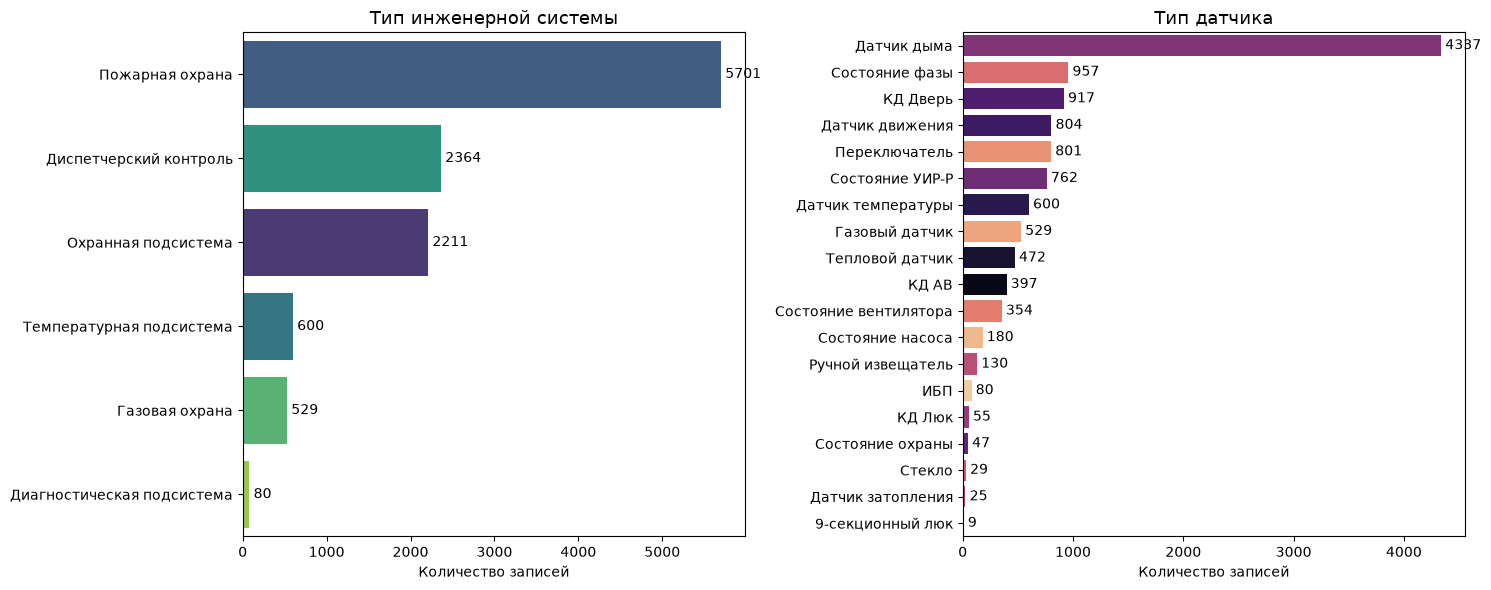

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

order1 = sensor_channel_df['тип_инж_системы'].value_counts().index
sns.countplot(
    data=sensor_channel_df, y='тип_инж_системы', order=order1,
    hue='тип_инж_системы', palette='viridis', legend=False, ax=axes[0]
)
axes[0].set_title('Тип инженерной системы', fontsize=13)
axes[0].set_xlabel('Количество записей'); axes[0].set_ylabel('')
for c in axes[0].containers:
    axes[0].bar_label(c, padding=3)

order2 = sensor_channel_df['тип_датчика'].value_counts().index
sns.countplot(
    data=sensor_channel_df, y='тип_датчика', order=order2,
    hue='тип_датчика', palette='magma', legend=False, ax=axes[1]
)
axes[1].set_title('Тип датчика', fontsize=13)
axes[1].set_xlabel('Количество записей'); axes[1].set_ylabel('')
for c in axes[1].containers:
    axes[1].bar_label(c, padding=3)

plt.tight_layout()
plt.show()

#### Датафрейм: OBJECTS_DF

In [10]:
if isFullAnalyzeMode:
    analyze_dataframe(objects_df, "objects_df")

optimize_df(objects_df)

---------------------------------------------------------------------------------------------------------------------------
 --- АНАЛИЗ ДАТАФЕЙМА: OBJECTS_DF
---------------------------------------------------------------------------------------------------------------------------

1. Основная информация:
   - Размер: 95 строк × 5 столбцов
   - Объем памяти: 0.01 MB

2. Столбцы и типы данных:
   - ид_объект            | Тип: int64        | Не null:     95 | Null:    0
   - иерархия_уровень     | Тип: int64        | Не null:     95 | Null:    0
   - родитель             | Тип: int64        | Не null:     95 | Null:    0
   - вид_объекта          | Тип: str          | Не null:     95 | Null:    0
   - диспетчерское_название_объекта | Тип: str          | Не null:     95 | Null:    0

3. Статистика по числовым колонкам:
       ид_объект  иерархия_уровень  родитель
count      95.00             95.00     95.00
mean     4095.01              2.81   2386.51
std      1908.92              0.42   

C:\Users\a.rodin\AppData\Local\Temp\2\ipykernel_14452\3315145165.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


,ид_объект,иерархия_уровень,родитель,вид_объекта,диспетчерское_название_объекта
0,5122,3,5,controlHouse,ДУ объект Альфа
1,5123,3,5,controlHouse,ДП объект Альфа
2,5124,3,5,controlHouse,ДП объект Альфа 2 этаж
3,5339,3,5,guardObject,объект Пси
4,5340,3,5,controlHouse,объект Пси шкаф ОПС
...,...,...,...,...,...
90,3828,2,5773,controlHouse,объект Мю
91,4068,2,5773,controlHouse,объект Сигма
92,4356,2,5773,controlHouse,ПС объект Ро
93,4573,2,5773,controlHouse,ПС объект Омега


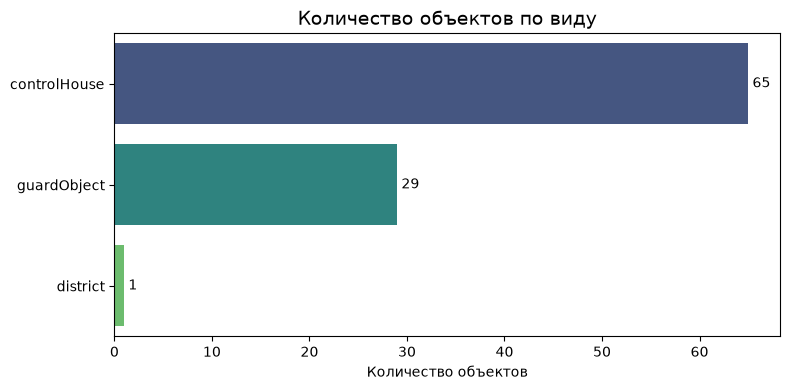

In [11]:
order = objects_df['вид_объекта'].value_counts().index

fig, ax = plt.subplots(figsize=(8, 4))
sns.countplot(
    data=objects_df,
    y='вид_объекта',
    order=order,
    hue='вид_объекта',
    palette='viridis',
    legend=False,
    ax=ax
)
ax.set_title('Количество объектов по виду', fontsize=14)
ax.set_xlabel('Количество объектов')
ax.set_ylabel('')

for c in ax.containers:
    ax.bar_label(c, padding=3)

plt.tight_layout()
plt.show()

In [12]:
hier = objects_df.copy()

hier['ид_объект'] = pd.to_numeric(hier['ид_объект'], errors='coerce').astype('Int64')
hier['родитель'] = pd.to_numeric(hier['родитель'], errors='coerce').astype('Int64')
hier['иерархия_уровень'] = pd.to_numeric(hier['иерархия_уровень'], errors='coerce').astype('Int64')

print('Всего объектов        :', len(hier))
print('Уникальных ид_объект  :', hier['ид_объект'].nunique())
print('Дубликаты id          :', hier['ид_объект'].duplicated().sum())
print('Корней (родитель NaN):', hier['родитель'].isna().sum())
print('Уровни                :', sorted(hier['иерархия_уровень'].dropna().unique()))

parent_ids = set(hier['родитель'].dropna())
child_ids = set(hier['ид_объект'].dropna())
orphans = parent_ids - child_ids
print('Родители, которых нет в таблице:', orphans)

children = (
    hier.dropna(subset=['родитель'])
        .groupby('родитель')['ид_объект']
        .apply(list)
        .to_dict()
)

row_by_id = hier.set_index('ид_объект').to_dict(orient='index')

roots = [
    i for i in hier['ид_объект']
    if pd.isna(hier.loc[hier['ид_объект'] == i, 'родитель'].iloc[0])
    or hier.loc[hier['ид_объект'] == i, 'родитель'].iloc[0] not in child_ids
]

print('Корней:', roots)

def print_tree(node_id, children, row_by_id, prefix='', is_last=True):
    row = row_by_id.get(node_id, {})
    name = row.get('диспетчерское_название_объекта', f'id={node_id}')
    kind = row.get('вид_объекта', '')
    level = row.get('иерархия_уровень', '')

    connector = '└── ' if is_last else '├── '
    print(f'{prefix}{connector}[{node_id}] {name} ({kind}, ур.{level})')

    kids = children.get(node_id, [])
    new_prefix = prefix + ('    ' if is_last else '│   ')
    for i, kid in enumerate(kids):
        print_tree(kid, children, row_by_id, new_prefix, i == len(kids) - 1)

if isFullAnalyzeMode:
    for r in roots:
        print_tree(r, children, row_by_id)

Всего объектов        : 95
Уникальных ид_объект  : 95
Дубликаты id          : 0
Корней (родитель NaN): 0
Уровни                : [np.int64(1), np.int64(2), np.int64(3)]
Родители, которых нет в таблице: {np.int64(3831)}
Корней: [np.int64(5773)]
└── [5773] Район по эксплуатации (district, ур.1)
    ├── [5] объект Альфа (controlHouse, ур.2)
    │   ├── [5122] ДУ объект Альфа (controlHouse, ур.3)
    │   ├── [5123] ДП объект Альфа (controlHouse, ур.3)
    │   ├── [5124] ДП объект Альфа 2 этаж (controlHouse, ур.3)
    │   ├── [5339] объект Пси (guardObject, ур.3)
    │   └── [5340] объект Пси шкаф ОПС (controlHouse, ур.3)
    ├── [6] объект Бета (controlHouse, ур.2)
    │   ├── [20] объект Фита (guardObject, ур.3)
    │   ├── [111] ДП объект Бета (controlHouse, ур.3)
    │   ├── [165] объект Бета (guardObject, ур.3)
    │   └── [4765] Шкаф ОПС объект Бета (controlHouse, ур.3)
    ├── [7] объект Гамма (controlHouse, ур.2)
    │   ├── [5961] объект Гамма ОС (guardObject, ур.3)
    │   ├── [59

#### Датафрейм: JOURNAL_DF

In [13]:
if isFullAnalyzeMode:
    analyze_dataframe(journal_df, "journal_df")

optimize_df(journal_df)

---------------------------------------------------------------------------------------------------------------------------
 --- АНАЛИЗ ДАТАФЕЙМА: JOURNAL_DF
---------------------------------------------------------------------------------------------------------------------------

1. Основная информация:
   - Размер: 30695389 строк × 6 столбцов
   - Объем памяти: 2192.28 MB

2. Столбцы и типы данных:
   - ид_события           | Тип: int64        | Не null: 30695389 | Null:    0
   - ид_канала_данных     | Тип: int64        | Не null: 30695389 | Null:    0
   - дата                 | Тип: str          | Не null: 30695389 | Null:    0
   - время                | Тип: str          | Не null: 30695389 | Null:    0
   - тревожное            | Тип: str          | Не null: 30695389 | Null:    0
   - значение_датчика     | Тип: str          | Не null: 30695389 | Null:    0

3. Статистика по числовым колонкам:
         ид_события  ид_канала_данных
count  3.069539e+07       30695389.00
mean   4

C:\Users\a.rodin\AppData\Local\Temp\2\ipykernel_14452\3315145165.py:25: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = df.select_dtypes(include=['object', 'category']).columns


  - Уникальных значений: 180
 - время:
  - Уникальных значений: 86400
 - тревожное:
  - Уникальных значений: 2
 - значение_датчика:
  - Уникальных значений: 4117

5. Пропущенные значения: Отсутствуют

6. Дубликаты:
   - Полных дубликатов строк: 0
---------------------------------------------------------------------------------------------------------------------------

Память: 2192.28 MB → 2075.19 MB (5.3% экономии)


,ид_события,ид_канала_данных,дата,время,тревожное,значение_датчика
0,4224123461,196736,2026-01-01,00:00:00,f,0.01
1,4224123463,196780,2026-01-01,00:00:00,f,0.02
2,4224123480,196753,2026-01-01,00:00:01,f,0.00
3,4224123486,213783,2026-01-01,00:00:02,f,0.12
4,4224123513,196729,2026-01-01,00:00:04,f,0.00
...,...,...,...,...,...,...
30695384,4476088637,230543,2026-06-30,23:59:50,f,0.06
30695385,4476088603,104047,2026-06-30,23:59:48,f,0.10
30695386,4476088604,104049,2026-06-30,23:59:48,f,0.02
30695387,4476088606,104065,2026-06-30,23:59:48,f,0.11


In [14]:
# Проверяем, что в "Тревожном" есть только значение true и false
if isFullAnalyzeMode:
    display(journal_df['тревожное'].unique())

<ArrowStringArray>
['f', 't']
Length: 2, dtype: str

In [15]:
# Заменяем значние на False на 0 и True на 1
journal_df['тревожное'] = (
    journal_df['тревожное']
    .map({'f': 0, 't': 1})
    .astype('int8')
)

#### Объединение данных

In [16]:
merged = journal_df.merge(
    sensor_channel_df[['ид_канала_данных', 'тип_инж_системы', 'тип_датчика','ид_объект']],
    on='ид_канала_данных',
    how='left'
)

print('Строк в журнале:', len(journal_df))
print('Строк после merge:', len(merged))
print('Не нашлось тип_датчика:', merged['тип_датчика'].isna().sum())

if isFullAnalyzeMode:
    display(merged.head())

Строк в журнале: 30695389
Строк после merge: 30695389
Не нашлось тип_датчика: 122


,ид_события,ид_канала_данных,дата,время,тревожное,значение_датчика,тип_инж_системы,тип_датчика,ид_объект
0,4224123461,196736,2026-01-01,00:00:00,0,0.01,Газовая охрана,Газовый датчик,5122.0
1,4224123463,196780,2026-01-01,00:00:00,0,0.02,Газовая охрана,Газовый датчик,5122.0
2,4224123480,196753,2026-01-01,00:00:01,0,0.00,Газовая охрана,Газовый датчик,5122.0
3,4224123486,213783,2026-01-01,00:00:02,0,0.12,Газовая охрана,Газовый датчик,4610.0
4,4224123513,196729,2026-01-01,00:00:04,0,0.00,Газовая охрана,Газовый датчик,5122.0


In [17]:
if isFullAnalyzeMode:
    summary = (
        merged
        .dropna(subset=['тип_датчика'])
        .groupby('тип_датчика')['значение_датчика']
        .agg(
            уникальных='nunique',
            всего_записей='count',
            примеры=lambda s: list(s.dropna().unique()[:10])
        ).sort_values('уникальных', ascending=False)
    )

    for tip, row in summary.iterrows():
        print('-'*123)
        print(f'Тип датчика     : {tip}')
        print(f'Всего записей   : {row["всего_записей"]}')
        print(f'Уникальных      : {row["уникальных"]}')
        print('Примеры:')
        for v in row['примеры']:
            print('   ', repr(v))

---------------------------------------------------------------------------------------------------------------------------
Тип датчика     : Состояние охраны
Всего записей   : 23097
Уникальных      : 3660
Примеры:
    '01.01.1970 03:00:00'
    'Снято с охраны'
    '01.01.1970 03:00:01'
    'На охране'
    '01.01.2026 07:54:05'
    'Неопределен'
    'Много неисправных устройств'
    'Норма'
    'Устройства на объекте исправны'
    '01.01.2026 11:13:33'
---------------------------------------------------------------------------------------------------------------------------
Тип датчика     : Газовый датчик
Всего записей   : 24709612
Уникальных      : 370
Примеры:
    '0.01'
    '0.02'
    '0.00'
    '0.12'
    '0.06'
    '0.05'
    '0.04'
    '0.83'
    '0.09'
    '0.03'
---------------------------------------------------------------------------------------------------------------------------
Тип датчика     : Датчик температуры
Всего записей   : 130373
Уникальных      : 78
Примеры:
  

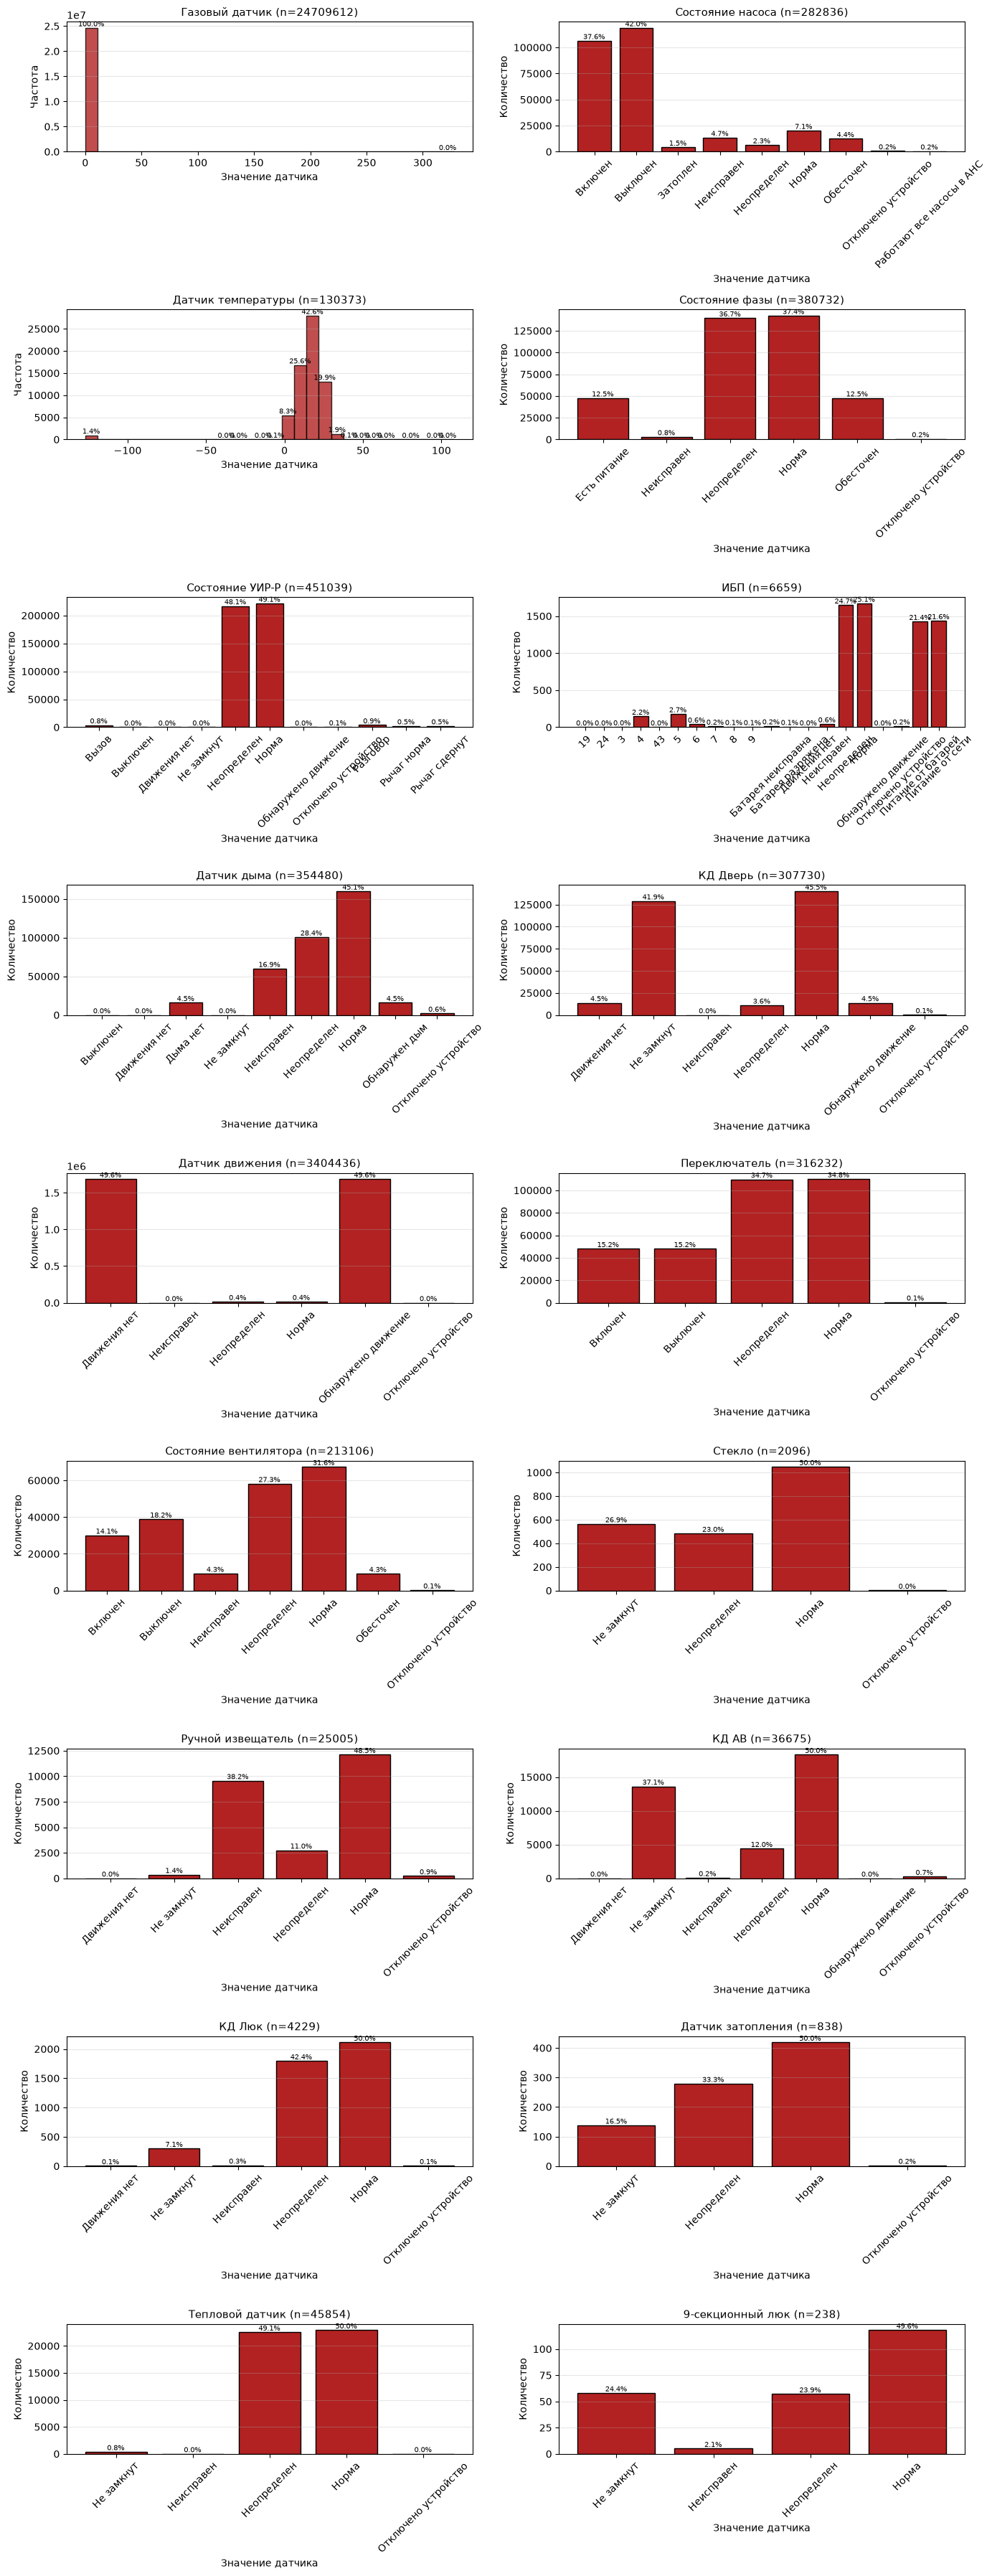

In [37]:
exclude_types = ['Состояние охраны']
sensor_types = [s for s in merged['тип_датчика'].dropna().unique()
                if s not in exclude_types]

# Типы, для которых нужно строить распределение (числовые)
numeric_types = ['Газовый датчик', 'Датчик температуры']

n = len(sensor_types)
ncols = 2
nrows = int(np.ceil(n / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(7 * ncols, 4 * nrows))
axes = axes.flatten()

for i, sensor in enumerate(sensor_types):
    subset = merged[merged['тип_датчика'] == sensor]
    ax = axes[i]

    if sensor in numeric_types:
        vals = pd.to_numeric(subset['значение_датчика'], errors='coerce').dropna()
        if len(vals) > 0:
            counts, bins, patches = ax.hist(vals, bins=30, color='firebrick',
                                            edgecolor='black', alpha=0.8)
            total = counts.sum()
            for c, p in zip(counts, patches):
                if c > 0:
                    ax.text(p.get_x() + p.get_width() / 2, c,
                            f'{c / total * 100:.1f}%',
                            ha='center', va='bottom', fontsize=7)
            ax.set_xlabel('Значение датчика')
            ax.set_ylabel('Частота')
        else:
            ax.text(0.5, 0.5, 'Нет числовых данных',
                    ha='center', va='center', transform=ax.transAxes)
    else:
        counts = subset['значение_датчика'].value_counts().sort_index()
        total = counts.sum()
        bars = ax.bar(counts.index.astype(str), counts.values,
                      color='firebrick', edgecolor='black')
        for b, c in zip(bars, counts.values):
            ax.text(b.get_x() + b.get_width() / 2, c,
                    f'{c / total * 100:.1f}%',
                    ha='center', va='bottom', fontsize=7)
        ax.set_xlabel('Значение датчика')
        ax.set_ylabel('Количество')
        ax.tick_params(axis='x', rotation=45)

    ax.set_title(f'{sensor} (n={len(subset)})', fontsize=11)
    ax.grid(axis='y', alpha=0.3)

# Скрыть пустые ячейки
for j in range(n, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

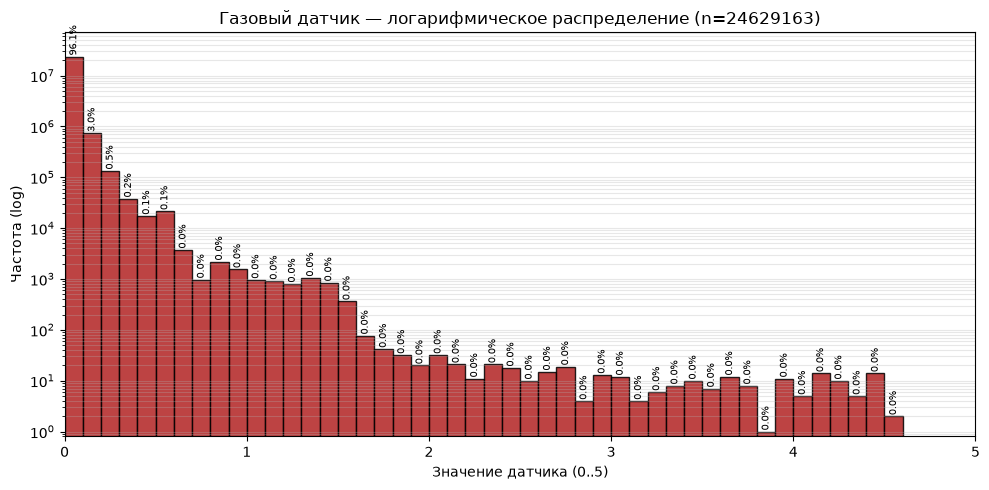

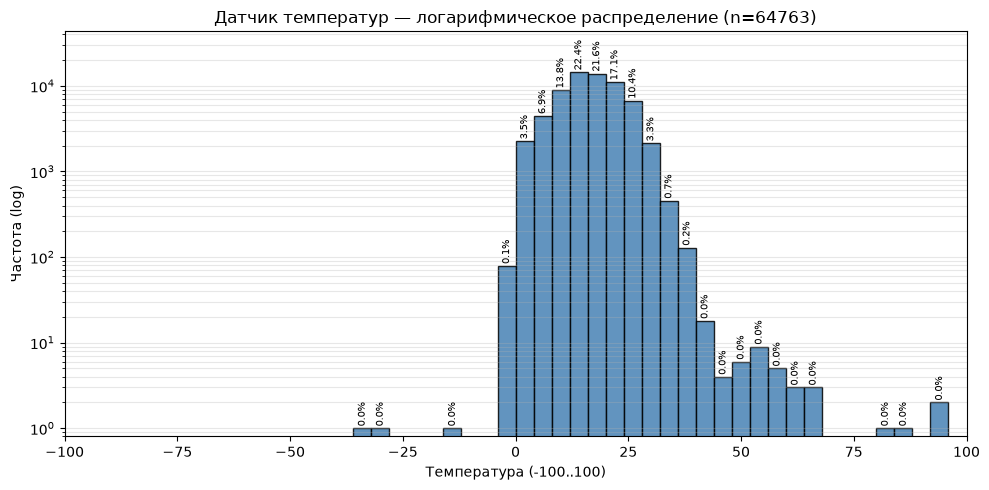

In [41]:
#  Газовый датчик: диапазон 0..5 
gas = merged[merged['тип_датчика'] == 'Газовый датчик'].copy()
gas_vals = pd.to_numeric(gas['значение_датчика'], errors='coerce').dropna()
gas_vals = gas_vals[(gas_vals >= 0) & (gas_vals <= 5)]

fig, ax = plt.subplots(figsize=(10, 5))
counts, bins, patches = ax.hist(gas_vals, bins=50, range=(0, 5),
                                color='firebrick', edgecolor='black', alpha=0.85)
total = counts.sum()
ymin = max(1, counts[counts > 0].min()) if (counts > 0).any() else 1
for c, p in zip(counts, patches):
    if c > 0:
        ax.text(p.get_x() + p.get_width() / 2, c * 1.05,
                f'{c / total * 100:.1f}%',
                ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_yscale('log')
ax.set_ylim(ymin * 0.8, counts.max() * 3)
ax.set_title(f'Газовый датчик — логарифмическое распределение (n={len(gas_vals)})', fontsize=12)
ax.set_xlabel('Значение датчика (0..5)')
ax.set_ylabel('Частота (log)')
ax.set_xlim(0, 5)
ax.grid(axis='y', alpha=0.3, which='both')
plt.tight_layout()
plt.show()


#  Датчик температур: диапазон -100..100 
temp = merged[merged['тип_датчика'] == 'Датчик температуры'].copy()
temp_vals = pd.to_numeric(temp['значение_датчика'], errors='coerce').dropna()
temp_vals = temp_vals[(temp_vals >= -100) & (temp_vals <= 100)]

fig, ax = plt.subplots(figsize=(10, 5))
counts, bins, patches = ax.hist(temp_vals, bins=50, range=(-100, 100),
                                color='steelblue', edgecolor='black', alpha=0.85)
total = counts.sum()
ymin = max(1, counts[counts > 0].min()) if (counts > 0).any() else 1
for c, p in zip(counts, patches):
    if c > 0:
        ax.text(p.get_x() + p.get_width() / 2, c * 1.05,
                f'{c / total * 100:.1f}%',
                ha='center', va='bottom', fontsize=7, rotation=90)
ax.set_yscale('log')
ax.set_ylim(ymin * 0.8, counts.max() * 3)
ax.set_title(f'Датчик температур — логарифмическое распределение (n={len(temp_vals)})', fontsize=12)
ax.set_xlabel('Температура (-100..100)')
ax.set_ylabel('Частота (log)')
ax.set_xlim(-100, 100)
ax.grid(axis='y', alpha=0.3, which='both')
plt.tight_layout()
plt.show()

**ВЫВОДЫ ПО ТИПАМ-ЗНАЧЕНИЯМ ДАТЧИКОВ**

 - тип_датчика (**19 типов датчиков**)
   
     - **'Стекло'**
  
       - 'Неопределен' - Состояние не удалось определить
       - 'Норма' - Датчик работает штатно
       - 'Не замкнут' - Срабатывание
       - 'Отключено устройство' - Датчик отключен

     - **'Датчик затопления'**
  
       - 'Неопределен' - Состояние не удалось определить
       - 'Норма' - Датчик работает штатно
       - 'Не замкнут' - Срабатывание
       - 'Неисправен' - Датчик неисправен

     - **'9-секционный люк'**
  
       - 'Неопределен' - Состояние не удалось определить
       - 'Норма' - Датчик работает штатно
       - 'Не замкнут' - Срабатывание
       - 'Неисправен' - Датчик неисправен

     - **'Переключатель'**
        - 'Включен' - Устройство находится в положении «вкл»
        - 'Выключен' - Устройство находится в положении «выкл»
        - 'Неопределен' - Состояние не удалось определить
        - 'Норма' - Датчик работает штатно
        - 'Отключено устройство' - Датчик отключен

     - **'Тепловой датчик'**
        - 'Неопределен' - Состояние не удалось определить
        - 'Норма' - Датчик работает штатно
        - 'Неисправен' - Датчик неисправен
        - 'Не замкнут' - Срабатывание (Тревога или обрыв)
        - 'Отключено устройство' - Датчик отключен

     - **'Состояние фазы'**
        - 'Неопределен'
        - 'Норма'
        - 'Есть питание' - Напряжение подано
        - 'Обесточен' - Питание пропало полностью
        - 'Неисправен'
        - 'Отключено устройство'

     - **'Ручной извещатель'** - ручной пожарный извещатель
        - 'Неопределен'
        - 'Норма'
        - 'Неисправен'
        - 'Не замкнут'
        - 'Движения нет' - Не относится. Скорее всего ошибка!
        - 'Отключено устройство'

     - **'КД Люк'**
        - 'Неопределен'
        - 'Норма'
        - 'Не замкнут'
        - 'Движения нет' - Не относится. Скорее всего ошибка!
        - 'Неисправен'
        - 'Отключено устройство'

     - **'Датчик движения'**
        - 'Обнаружено движение'
        - 'Движения нет' - Движение не обнаружено
        - 'Неопределен' - Зафиксировано перемещение — событие / тревога
        - 'Норма'
        - 'Неисправен'
        - 'Отключено устройство'

     - **'КД Дверь'** - концевой датчик (контактное устройство) двери
        - 'Не замкнут' - Дверь открыта. Срабатывание
        - 'Норма'
        - 'Неопределен'
        - 'Обнаружено движение' - Не относится. Скорее всего ошибка!
        - 'Движения нет' - Не относится. Скорее всего ошибка!
        - 'Неисправен'
        - 'Отключено устройство'

     - **'КД АВ'** - концевой датчик АВ (Аварийный ввод)
        - 'Неопределен'
        - 'Норма'
        - 'Не замкнут'
        - 'Отключено устройство'
        - 'Неисправен'
        - 'Движения нет' - Не относится. Скорее всего ошибка!
        - 'Обнаружено движение' - Не относится. Скорее всего ошибка!

     - **'Состояние вентилятора'**
         - 'Неисправен'
         - 'Обесточен' - Питание пропало — щит/линия без напряжения
         - 'Норма'
         - 'Выключен' - Вентилятор выключен (по команде или по режиму)
         - 'Включен' - Вентилятор включён (команда подана, работает)
         - 'Неопределен'
         - 'Отключено устройство'

     - **'Состояние насоса'**
         - 'Включен' - Насос включён (команда подана, работает)
         - 'Выключен' - Насос выключен (по команде или режиму)
         - 'Норма'
         - 'Неисправен'
         - 'Обесточен' - Питание пропало — щит/линия без напряжения
         - 'Затоплен' - Авария (критическая)
         - 'Отключено устройство'
         - 'Неопределен'
         - 'Работают все насосы в АНС' - Не состояние одного насоса. Какой-то сводный статус группы насосов

     - **'Датчик дыма'**
        - 'Неисправен'
        - 'Норма'
        - 'Обнаружен дым' - Зафиксирован дым — пожарная тревога
        - 'Дыма нет' - Дым не обнаружен
        - 'Неопределен'
        - 'Отключено устройство'
        - 'Выключен'
        - 'Не замкнут' - Срабатывание
        - 'Движения нет' - Не относится. Скорее всего ошибка!

     - **'Состояние УИР-Р'** - Устройство Извещения Речевое — Рупорное
        - 'Неопределен'
        - 'Норма'
        - 'Вызов' - Поступил вызов
        - 'Разговор' - Установлено соединение, идёт разговор
        - 'Отключено устройство'
        - 'Рычаг сдернут' - Механический рычаг сдёрнут — срабатывание
        - 'Рычаг норма'
        - 'Не замкнут'
        - 'Движения нет' - Не относится. Скорее всего ошибка!
        - 'Обнаружено движение' - Не относится. Скорее всего ошибка!
        - 'Выключен'
     - **'ИБП'**
        - 'Питание от батарей' - авария
        - 'Питание от сети' - ИБП питает нагрузку от сети (штатный режим)
        - 'Неисправен'
        - 'Неопределен'
        - 'Норма'
        - 'Батарея неисправна' - Батарея вышла из строя, требует замены
        - 'Батарея разряжена' - Батарея почти пуста — критическое состояние
        - 'Движения нет' - Не относится. Скорее всего ошибка!
        - 'Обнаружено движение' - Не относится. Скорее всего ошибка!
        - 'Отключено устройство'        - 
        - '3', '4', '5', '6', '8', '7', '9', '19', '24', '43' (данных с цифрами немного - можно удалить)
     - **'Датчик температуры'** - содержит числовые значение + текстовые. Нужно разделять на 2 колонки.
        - 'Температура ниже 3ºC'
        - 'Неисправен'
        - 'Норма'
     - **'Газовый датчик'** - содержит числовые значение + текстовые. Нужно разделять на 2 колонки.
        - 'Неопределен'
        - 'Норма'
     - **'Состояние охраны'** - содержит числовые значение + даты. Дат очень много. Скорее всего, даты означают постановку на охрану. Если это так, то нужно заменить даты на "На охране"
        - 'Снято с охраны' - Объект снят с охраны (люди внутри, обход, обслуживание)
        - 'На охране' - Объект под охраной, всё активно
        - 'Неопределен'
        - 'Много неисправных устройств' - Массовый отказ оборудования на объекте
        - 'Норма'
        - 'Устройства на объекте исправны' - Все датчики/устройства работают

#### Анализ переменной "Тревожное"
Это значение не является целевой переменной. Целевую переменную надо сформировать!

In [42]:
TARGET = 'тревожное'

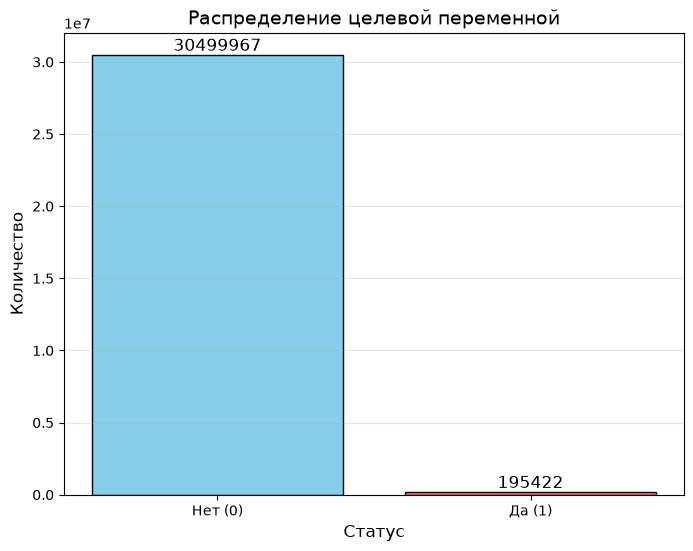

In [43]:
plt.figure(figsize=(8, 6))
counts = merged[TARGET].value_counts()
colors = ['skyblue', 'lightcoral']
bars = plt.bar(['Нет (0)', 'Да (1)'], counts.values, color=colors, edgecolor='black')

# Добавление значений на столбцы
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
             f'{int(height)}', ha='center', va='bottom', fontsize=12)

plt.title('Распределение целевой переменной', fontsize=14)
plt.xlabel('Статус', fontsize=12)
plt.ylabel('Количество', fontsize=12)
plt.grid(axis='y', alpha=0.3)
plt.show()

In [44]:
value_counts = merged[TARGET].value_counts().sort_index()

# Дисбаланс классов
min_class = min(value_counts)
max_class = max(value_counts)
imbalance_ratio = max_class / min_class
print("-"*123)
print("ДИСБАЛАНС КЛАССОВ:")
print("-"*123)
print(f"Соотношение классов (макс/мин): {imbalance_ratio:.2f}:1")
if imbalance_ratio > 1.5:
    print("Обнаружен значительный дисбаланс классов!")
    if imbalance_ratio > 3:
        print("Сильный дисбаланс (>3:1)")
    else:
        print("Умеренный дисбаланс (1.5-3:1)")
else:
    print("Классы сбалансированы!")

---------------------------------------------------------------------------------------------------------------------------
ДИСБАЛАНС КЛАССОВ:
---------------------------------------------------------------------------------------------------------------------------
Соотношение классов (макс/мин): 156.07:1
Обнаружен значительный дисбаланс классов!
Сильный дисбаланс (>3:1)


### Подготовка данных под "Пожарный риск"

Пожарный риск — это не одна модель/один сигнал, а совокупность сигналов.
Одни датчики являются прямыми признаками пожара, другие — косвенные (можно сказать предвестники пожара).

#### Идеи, положенные в основу модели подготовки данных

**1. Прямые признаки пожара (ядро модели)**

| Тип датчика | Значения | Роль в ML модели |
|---|---|---|
| Датчик дыма | Обнаружен дым, Не замкнут | Главный признак. Дым — самый ранний признак возгорания |
| Тепловой датчик | Не замкнут | Второй по важности. Реагирует на развитое горение/нагрев |
| Ручной извещатель | Не замкнут | Подтверждение. Человек нажал кнопку — значит, видит пожар |

**2. Косвенные признаки (усиливают модель)**

Это датчики, которые не фиксируют пожар напрямую, но их срабатывание коррелирует с пожаром или предшествует ему.

| Тип датчика | Значения | Роль в ML модели |
|---|---|---|
|Газовый датчик|Срабатывание|Утечка газа — частая причина пожара/взрыва|
|Состояние фазы|Обесточен|Потеря питания — риск для систем безопасности, также может быть следствием пожара|
|ИБП|Питание от батарей, Батарея разряжена|Отказ резервного питания — риск отказа систем пожаротушения|
Датчик затопления|Не замкнут|Вода + электрика = риск короткого замыкания и пожара
Состояние насоса|Затоплен, Неисправен, Обесточен|Насосы пожаротушения должны быть в готовности; их отказ — риск
Состояние вентилятора|Неисправен, Обесточен|Вентиляторы дымоудаления должны быть готовы
Стекло|Не замкнут|Может быть признаком поджога (разбитие окна)
КД Дверь|Не замкнут|Открытые двери — нарушение противопожарного режима
КД Люк|Не замкнут|Открытые люки — доступ воздуха к очагу
КД АВ|Не замкнут|Отключённый ввод — риск для систем безопасности
Датчик температуры|Выше какого-то значения и рост|Рост температуры - может быть пожар

Сами по себе они не значат пожар, но в комбинации с прямыми признаками — резко повышают уверенность.

#### Единая карта правил

In [45]:
# Уровни (логика описана выше)
LEVELS = ['drop',     # будем удалять!
          'ok',       # штатно
          'no_data',  # состояние не определено
          'risk',     # фактор риска
          'presence', # присутствие людей/работы
          'gas',      # превышение порога газа
          'fire']     # пожар

# Правила
RULES = {
    'Датчик дыма': {
        'Обнаружен дым': 'fire', 'Не замкнут': 'fire',
        'Норма': 'ok', 'Дыма нет': 'ok', 'Выключен': 'risk',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
    },
    'Тепловой датчик': {
        'Не замкнут': 'fire', 'Норма': 'ok',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
        'Выключен': 'risk',
    },
    'Ручной извещатель': {
        'Не замкнут': 'fire', 'Норма': 'ok',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
        'Рычаг сдернут': 'fire', 'Рычаг норма': 'ok', 'Выключен': 'risk',
    },
    'Газовый датчик': {
        'Обнаружен газ': 'gas', 'Срабатывание': 'gas', 
        'Норма': 'ok', 'Неопределен': 'no_data',
        'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Выключен': 'risk',
    },
    'Датчик температуры': {
        'Норма': 'ok', 'Неисправен': 'risk', 'Неопределен': 'no_data',
        'В норме от +3 до +40': 'ok', 'Температура выше 40ºC': 'risk',
        'Отключено устройство': 'risk', 'Выключен': 'risk',
        'Температура ниже 3ºC': 'ok', 'Движения нет': 'ok',
    },
    'Стекло': {'Не замкнут': 'risk', 'Норма': 'ok', 'Неопределен': 'no_data', 
               'Отключено устройство': 'risk', 'Выключен': 'risk',
              },
    'КД Дверь': {
        'Не замкнут': 'presence', 'Движения нет': 'ok', 'Обнаружено движение': 'presence',
        'Норма': 'ok', 'Неопределен': 'no_data', 'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Выключен': 'risk',
    },
    'КД Люк': {
        'Не замкнут': 'presence',
        'Норма': 'ok', 'Неисправен': 'risk', 'Отключено устройство': 'risk', 'Неопределен': 'no_data',
         'Выключен': 'risk',
    },
    'КД АВ': {
        'Не замкнут': 'presence',
        'Норма': 'ok', 'Неопределен': 'no_data', 'Неисправен': 'risk', 'Отключено устройство': 'risk',
        'Выключен': 'risk',
    },
    'Датчик движения': {
        'Обнаружено движение': 'presence', 'Не замкнут': 'presence', 'Движения нет': 'ok', 'Норма': 'ok',
        'Неисправен': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data', 'Выключен': 'ok',
    },
    'Датчик затопления': {'Норма': 'ok', 'Не замкнут': 'risk', 'Неисправен': 'risk',
                          'Неопределен': 'no_data', 'Отключено устройство': 'risk'},
    'Состояние фазы': {
        'Обесточен': 'risk', 'Неисправен': 'risk', 'Выключен': 'risk', 'Включен': 'ok',
        'Есть питание': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data',
    },
    'ИБП': {
        'Питание от батарей': 'risk', 'Батарея разряжена': 'risk', 'Батарея неисправна': 'risk',
        'Неисправен': 'risk',
        'Питание от сети': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data',
        'Выключен': 'ok',
    },
    'Состояние насоса': {
        'Затоплен': 'risk', 'Неисправен': 'risk', 'Обесточен': 'risk',
        'Включен': 'ok', 'Выключен': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok',
        'Неопределен': 'no_data', 'Работают все насосы в АНС': 'ok',
    },
    'Состояние вентилятора': {
        'Неисправен': 'risk', 'Обесточен': 'risk',
        'Включен': 'ok', 'Выключен': 'ok', 'Норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data',
    },
    'Состояние УИР-Р': {
        'Рычаг сдернут': 'risk', 'Не замкнут': 'risk', 'Неисправен': 'risk',
        'Вызов': 'presence', 'Разговор': 'presence',
        'Норма': 'ok', 'Рычаг норма': 'ok', 'Отключено устройство': 'ok', 'Неопределен': 'no_data', 'Выключен': 'ok',
    },
    'Состояние охраны': {
        'Норма': 'ok', 'На охране': 'ok', 'Устройства на объекте исправны': 'ok',
        'Снято с охраны': 'presence',
        'Много неисправных устройств': 'risk', 'Неопределен': 'no_data', 'Выключен': 'risk',
    },
    'Переключатель': {}, '9-секционный люк': {},
}

## 4. ВЫВОДЫ

1.	Журналы событий содержат большое количество строк. Число строк измеряются десятками миллионов записей. Анализировать события, размещая их в памяти, не очень хороший вариант. Необходимо использовать потоковый анализ данных и свертку. Предварительно часовую.

Пример, загрузка одного файла 2026 года
 - Строк: 30 695 389
 - Столбцов: 6
 - Объем памяти, который был занят при считывании 5Гб.

3.	Поле "Тревожное" содержит значение true и false. Данное поле показывает то, что что-то происходит с датчиками. Оно нам никак не подходит в качестве TARGET (пожар). Данную целевую переменную для обучения нам придется формировать самостоятельно. Поле тревожное (как и сам пожар) – это явление редкое, т.е. мы тут имеем **существенный дисбаланс классов**.

4.	Были проанализированы все записи, которые попадают в поле «Значение». Поле значение может содержать как текстовое описание (справочник), так и числовые. Был сформирован справочник ТИП-ЗНАЧЕНИЕ.

5.	Для построения модели был выбран следующий подход «Пожарный риск — это не одна модель/один сигнал, а совокупность сигналов. Одни датчики являются прямыми признаками пожара, другие — косвенные (можно сказать предвестники пожара).»
